# Tool Wear Regression — XGBoost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [6]:
df = pd.read_csv('/content/clustered_data.csv')
print(df.shape)
print(df.head())


(2645, 46)
   udi type  air_temperature  process_temperature  rotational_speed  torque  \
0    1    M            298.1                308.6              1551    42.8   
1    2    L            298.2                308.7              1408    46.3   
2    3    L            298.1                308.5              1498    49.4   
3    4    L            298.2                308.6              1433    39.5   
4    5    L            298.2                308.7              1408    40.0   

   tool_wear  machine_failure  twf  hdf  ...  tool_wear_roll_mean_5  \
0          0                0    0    0  ...               0.000000   
1          3                0    0    0  ...               1.500000   
2          5                0    0    0  ...               2.666667   
3          7                0    0    0  ...               3.750000   
4          9                0    0    0  ...               4.800000   

   tool_wear_roll_std_5  tool_wear_delta  tool_wear_lag1       PC1       PC2  \
0      

In [7]:
FEATURES = ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'type_enc', 'udi']
TARGET   = ['tool_wear']

X = df[FEATURES]
y = df[TARGET]


In [25]:
df['temp_diff'] = df['process_temperature'] - df['air_temperature']
FEATURES = ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'type_enc', 'udi', 'temp_diff']
X = df[FEATURES]
y = df[TARGET]

In [12]:
train_size = int(0.8 * len(X))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [13]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
#print(f'Train: {X_train.shape[0]}  Test: {X_test.shape[0]}')


Train: 2116  Test: 529


In [14]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

In [16]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R2   : {r2:.4f}')

MAE  : 22.5412
RMSE : 32.1999
R2   : 0.7409


In [18]:
results = pd.DataFrame({'Actual': y_test['tool_wear'].values[:10], 'Predicted': y_pred[:10].round(2)})
print(results.to_string(index=False))

 Actual  Predicted
    115 109.669998
    178 148.570007
     75  63.150002
     90  94.230003
    144 140.429993
     19  50.830002
     53  62.049999
     39  69.790001
    197 138.729996
    130 139.009995


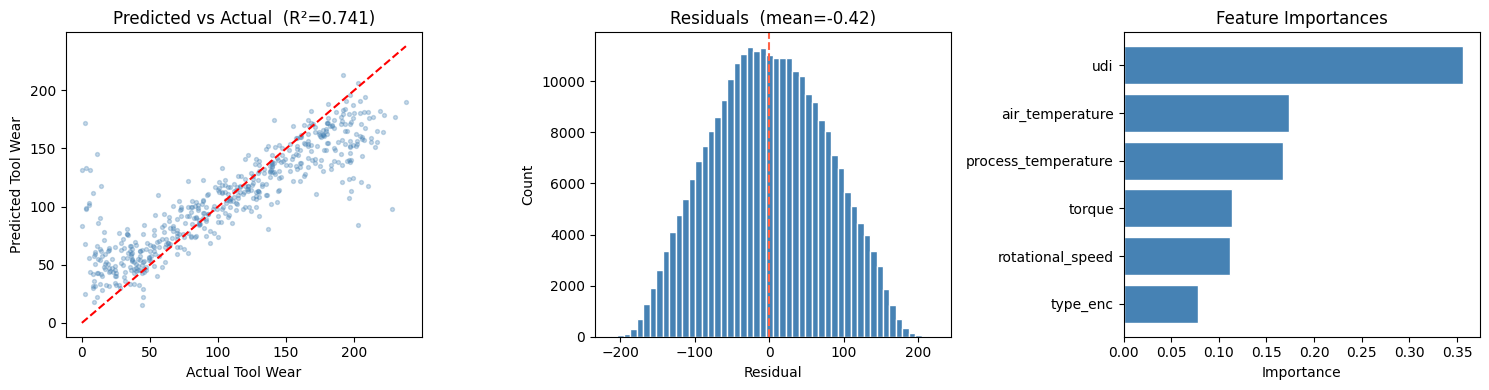

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue')
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Tool Wear'); axes[0].set_ylabel('Predicted Tool Wear')
axes[0].set_title(f'Predicted vs Actual  (R²={r2:.3f})')

# Residuals
residuals = y_test.values - y_pred
axes[1].hist(residuals.flatten(), bins=50, color='steelblue', edgecolor='white') # Flatten residuals
axes[1].axvline(0, color='tomato', lw=1.5, ls='--')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals  (mean={residuals.mean():.2f})')


if len(model.feature_importances_) != len(FEATURES):

    imp = pd.Series(model.feature_importances_, index=FEATURES[:len(model.feature_importances_)]).sort_values()
else:
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
axes[2].barh(imp.index, imp.values, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Importance'); axes[2].set_title('Feature Importances')

plt.tight_layout(); plt.show()

In [24]:
joblib.dump(model, 'tool_wear_regressor.pkl')
print('Saved: tool_wear_regressor.pkl')


Saved: tool_wear_regressor.pkl
